In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

df_valid = pd.read_csv('../data/processed/all_airports_clean.csv')

df_valid['scheduled_dep_datetime'] = pd.to_datetime(df_valid['scheduled_dep_datetime'])
df_valid['hour'] = df_valid['scheduled_dep_datetime'].dt.hour
df_valid['weekday'] = df_valid['scheduled_dep_datetime'].dt.dayofweek
df_valid['month'] = df_valid['scheduled_dep_datetime'].dt.month

print(f"数据重新加载完成，形状: {df_valid.shape}")

数据重新加载完成，形状: (11269654, 18)


In [ ]:

df_sample = df_valid.sample(n=1000000, random_state=42).copy()

df_sample['is_delayed'] = (df_sample['departure_delay_min'] > 15).astype(int)

df_model = pd.get_dummies(df_sample, columns=['dep_airport', 'arr_airport'], prefix=['dep', 'arr'])

feature_cols = ['hour', 'weekday', 'month'] + [c for c in df_model.columns if c.startswith('dep_') or c.startswith('arr_')]

X = df_model[feature_cols]
y = df_model['is_delayed']

print(f"特征矩阵大小: {X.shape}")
print(f"延误样本比例: {y.mean():.2%}")

特征矩阵大小: (1000000, 882)
延误样本比例: 59.03%


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
import joblib

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("正在训练模型，请稍候（可能需要几十秒）...")

rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

rf.fit(X_train, y_train)
print("模型训练完成！")

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("\n模型评估报告：")
print(classification_report(y_test, y_pred, target_names=['准点', '延误']))
print(f"ROC-AUC 分数: {roc_auc_score(y_test, y_prob):.4f}")

joblib.dump(rf, '../src/delay_model.pkl')
print("\n模型已保存至 src/delay_model.pkl")

正在训练模型，请稍候（可能需要几十秒）...
模型训练完成！

模型评估报告：
              precision    recall  f1-score   support

          准点       0.53      0.62      0.57     81940
          延误       0.70      0.62      0.66    118060

    accuracy                           0.62    200000
   macro avg       0.61      0.62      0.61    200000
weighted avg       0.63      0.62      0.62    200000

ROC-AUC 分数: 0.6625

模型已保存至 src/delay_model.pkl


C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 24310 (\N{CJK UNIFIED IDEOGRAPH-5EF6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 35823 (\N{CJK UNIFIED IDEOGRAPH-8BEF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\l\AppData\Local\Temp\ipykernel_24504\925935965.py:11: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884})

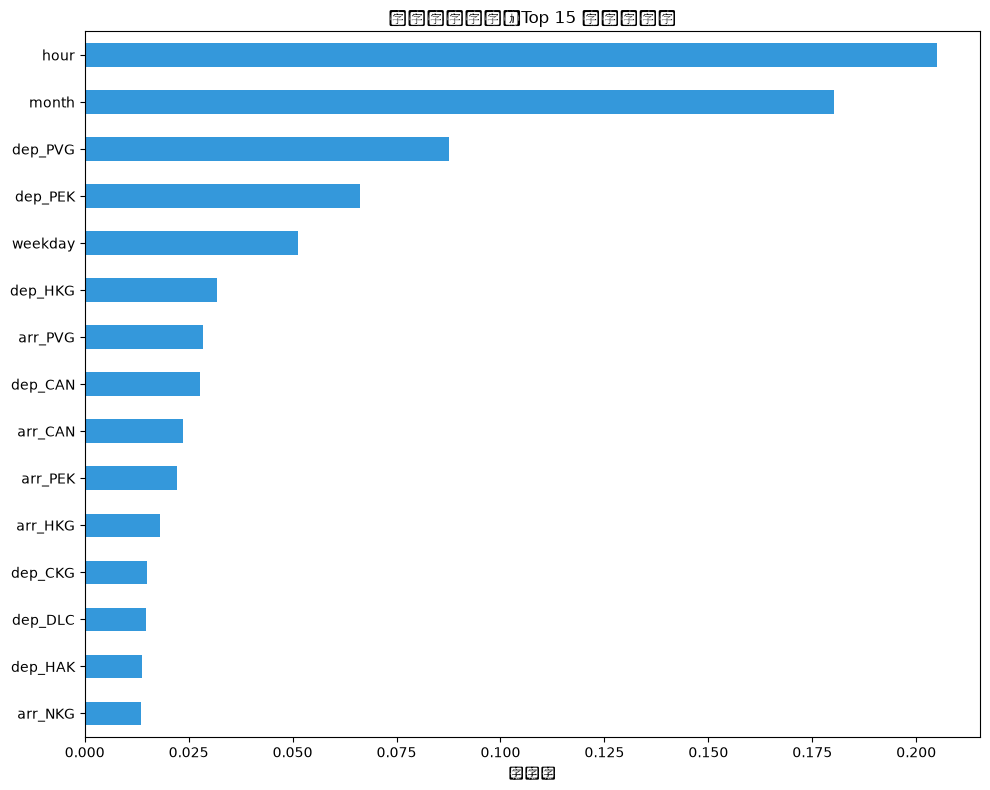

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.tail(15).plot(kind='barh', color='#3498db')
plt.xlabel('重要性')
plt.title('延误预测模型：Top 15 最重要特征')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance.png', dpi=150)
plt.show()

In [7]:
import pandas as pd
import joblib

model = joblib.load('../src/delay_model.pkl')

input_df = pd.DataFrame(0, index=[0], columns=model.feature_names_in_)

input_df['hour'] = 8
input_df['weekday'] = 2   # 周三
input_df['month'] = 6

dep_col = 'dep_airport_PEK'
arr_col = 'arr_airport_SHA'
if dep_col in input_df.columns:
    input_df[dep_col] = 1
if arr_col in input_df.columns:
    input_df[arr_col] = 1

prob = model.predict_proba(input_df)[0][1]

print(f"✈️ 模拟航班: PEK → SHA，周三 08:00 出发")
print(f"⚠️ 模型预测延误（>15分钟）的概率为: {prob:.1%}")

if prob > 0.6:
    print("⚠️ 高风险：建议提前做好预案。")
elif prob > 0.4:
    print("🟡 中风险：保持关注。")
else:
    print("🟢 低风险：准点概率较高。")

✈️ 模拟航班: PEK → SHA，周三 08:00 出发
⚠️ 模型预测延误（>15分钟）的概率为: 51.0%
🟡 中风险：保持关注。
